1.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

2.

In [5]:
abandon_df = pd.read_csv('cart_abandon.csv')

3.

<Axes: xlabel='user_type', ylabel='time_on_site'>

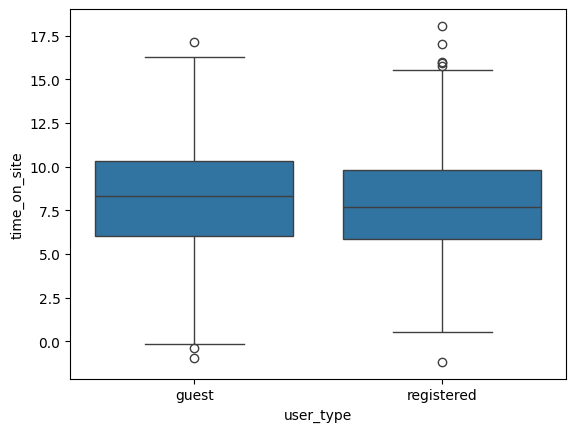

In [6]:
sns.boxplot(data=abandon_df, x='user_type', y='time_on_site')

In [ ]:
답03 = '2'

4.

In [7]:
abandon_df['time_on_site'].fillna(abandon_df['time_on_site'].median(), inplace=True)

abandon_df['cart_value'].fillna(abandon_df['cart_value'].mean(), inplace=True)

/tmp/ipykernel_1649/2034380168.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  abandon_df['time_on_site'].fillna(abandon_df['time_on_site'].median(), inplace=True)
/tmp/ipykernel_1649/2034380168.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

5.

In [8]:
abandon_df["prev_purchase"] = abandon_df["prev_purchase"].map({"Y": 1, "N": 0})
abandon_df["discount_applied"] = abandon_df["discount_applied"].map({"Y": 1, "N": 0})
abandon_df["user_type"] = abandon_df["user_type"].map({"registered": 1, "guest": 0})

In [9]:
cat_col = ['device', 'country', 'payment_method']

In [10]:
incoding_df = pd.get_dummies(data=abandon_df, columns=cat_col, drop_first=True)

6.

In [11]:
incoding_df.drop(columns=['num_items'], axis=1, inplace=True)

7.

In [12]:
filtering_df = incoding_df.drop(incoding_df[incoding_df['time_on_site'] < 0].index, axis=0)
filtering_df.reset_index(drop=True, inplace=True)

8.

In [14]:
X = filtering_df.drop(columns=['cart_abandon_yn'])
y = filtering_df['cart_abandon_yn']

9.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

10.

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)

11.

In [18]:
from sklearn.ensemble import RandomForestClassifier

In [19]:
rfc = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)

rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, random_state=42)

12.

In [20]:
from xgboost import XGBClassifier

In [21]:
xgbc = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)

xgbc.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

13.

In [22]:
from sklearn.metrics import accuracy_score, f1_score, precision_score

In [24]:
rfc_predict = rfc.predict(X_test)

xgbc_predict = xgbc.predict(X_test)

print('RFC')
print('ACC :', accuracy_score(y_valid, rfc_predict))
print('F1 :', f1_score(y_valid, rfc_predict))

print('XGBC')
print('ACC :', accuracy_score(y_valid, xgbc_predict))
print('F1 :', f1_score(y_valid, xgbc_predict))

RFC
ACC : 0.6653846153846154
F1 : 0.02247191011235955
XGBC
ACC : 0.6384615384615384
F1 : 0.17543859649122806


14.

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
y_train = to_categorical(y_train, num_classes=2)
y_valid = to_categorical(y_valid, num_classes=2)

In [27]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=50, batch_size=128, validation_data=(X_valid, y_valid))

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6371 - loss: 0.6579 - val_accuracy: 0.6692 - val_loss: 26.4828
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6641 - loss: 0.6362 - val_accuracy: 0.6692 - val_loss: 21.4977
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6728 - loss: 0.6287 - val_accuracy: 0.6692 - val_loss: 18.4957
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6747 - loss: 0.6246 - val_accuracy: 0.6692 - val_loss: 17.4193
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6747 - loss: 0.6209 - val_accuracy: 0.6692 - val_loss: 17.0501
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6728 - loss: 0.6174 - val_accuracy: 0.6692 - val_loss: 16.6449
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6757 - loss: 0.6141 - val_accuracy: 0.6692 - val_loss: 16.1572
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6766 - loss: 0.6110 - val_accuracy: 0.6692 - val_loss: 15.7